# 03 · 深挖篇：口径、选择与预算

`02-实战篇` 复现了报告的主线数字；本笔记本回答三个更"钻"的问题：

1. **选择规则**到底能不能用一句话讲清？（first-verified / max-survivor / 非最高频）
2. `p_model` 与经验频率的**失准**长什么样？（散点图 + fate_m_009 逐 token 案例）
3. 把预算 `B'` 当参数**扫一遍**：哪道题最"吃预算"？需要多少才稳？（B90 线）

前置：可先跑 `02-实战篇` 的第一个单元（自动准备数据），本笔记本也会重复准备逻辑。

In [1]:
import json
import math
import os
import glob
import zipfile
import collections
from pathlib import Path

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
%matplotlib inline

plt.rcParams["font.sans-serif"] = ["Noto Sans CJK SC", "WenQuanYi Zen Hei", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False

def find_repo_root(start=None):
    start = Path(start or Path.cwd()).resolve()
    for d in [start, *start.parents]:
        if (d / "hsy-的分析").is_dir():
            return d
    for cand in [Path.home() / "10-4-alpha-proof",
                 Path("/mnt/gloway/projects/10-4-alpha-proof")]:
        if (cand / "hsy-的分析").is_dir():
            return cand
    return None

E2 = Path(os.environ.get("E2_WORK", "~/e2-work")).expanduser()
TRAIN = E2 / "training/remote/tmp/fate-m-formal-w001-shared-rollout-v2"
JOIN  = E2 / "join/remote/tmp/fate-m-formal-w001-join-v2/joins"

def ensure_data():
    if TRAIN.is_dir() and JOIN.is_dir():
        return "已就绪"
    repo = find_repo_root()
    assert repo is not None, "找不到仓库根目录（应包含 hsy-的分析/）"
    ev = repo / "hsy-的分析/extracted/modelscope_ce_online_delivery_20261006/evidence"
    for sub, name in [("training", "training_initial_evidence_20261006.zip"),
                      ("join", "join_v2_evidence_20261006.zip")]:
        with zipfile.ZipFile(ev / name) as z:
            z.extractall(E2 / sub)
    return "已从证据包解压"

print("数据状态:", ensure_data())

数据状态: 已就绪


## 0. 复用加载器

In [2]:
def iter_problems():
    return sorted(d.name for d in TRAIN.iterdir() if d.name.startswith("fate_m_"))

def load_request(p):
    reqs = sorted(glob.glob(str(TRAIN / p / "actor_receipts" / "*" / "policy_requests" / "*.json")))
    return json.loads(Path(reqs[0]).read_text())

def load_problem(p):
    cands = load_request(p)["candidates"]
    canon, results, selected = {}, {}, None
    for line in (TRAIN / p / "observer.jsonl").read_text().splitlines():
        ev = json.loads(line)
        kind = ev.get("kind")
        if kind == "canonical_candidate":
            canon[ev["candidate_index"]] = ev
        elif kind == "canonical_candidate_result":
            results[ev["candidate_index"]] = ev
        elif kind == "canonical_selected_path":
            selected = ev
    sel_ids = set(selected.get("selected_event_ids", [])) if selected else set()
    rows = []
    for ci, ev in canon.items():
        res = results.get(ci, {})
        rc = cands[ev["survivor_sample_index"]]
        rows.append({
            "problem": p,
            "ci": ci,
            "action": ev["action"],
            "k": len(ev["sample_indices"]),
            "survivor": ev["survivor_sample_index"],
            "logp_old": sum(rc["raw_completion_old_logprobs"]),
            "logp_samp": sum(rc["raw_completion_sampling_logprobs"]),
            "status": res.get("verifier_status"),
            "selected": ev.get("event_id") in sel_ids,
            "sequence": int(ev.get("sequence", 0)),
            "event_id": ev.get("event_id"),
        })
    return rows, selected

B, DELTA = 64, 0.1
THETA = math.log(1 / DELTA) / B
ALL = []
for p in iter_problems():
    rows, _ = load_problem(p)
    ALL.extend(rows)
print("canonical 候选总数:", len(ALL))

CHECKS = []
def check(name, got, want, tol=None):
    ok = abs(got - want) <= tol if tol is not None else got == want
    CHECKS.append((name, ok))
    print(("✓" if ok else "✗"), f"{name}: {got}" + ("" if ok else f"  （期望 {want}）"))

canonical 候选总数: 233


---
## 1. 选择规则核验

报告陈述的规则："selected = 评估顺序上最早通过验证的候选"，等价观察：
"已验证候选中 survivor 样本序号最大者"。三个可检验的命题：

- P1: selected 的 sequence == 已验证候选的最小 sequence（20/20）
- P2: selected 的 survivor == 已验证候选的最大 survivor（20/20）
- P3: selected 并非最高频：9/20 题存在更常见的已验证变体

In [3]:
rows_by_problem = {}
for p in iter_problems():
    rows, _ = load_problem(p)
    rows_by_problem[p] = rows

print(f"{'problem':>22} {'选k':>4} {'maxk':>5} {'sel序列':>7} {'首验序列':>8} {'sel-surv':>8} {'max-surv':>8}")
p1_ok = p2_ok = 0
notmax = []
for p in iter_problems():
    rows = rows_by_problem[p]
    vrows = [r for r in rows if r["status"] == "verified_proof"]
    srow  = next(r for r in rows if r["selected"])
    first_seq = min(r["sequence"] for r in vrows)
    max_surv  = max(r["survivor"] for r in vrows)
    max_k     = max(r["k"] for r in vrows)
    p1_ok += (srow["sequence"] == first_seq)
    p2_ok += (srow["survivor"] == max_surv)
    if srow["k"] < max_k:
        notmax.append((p, srow["k"], max_k))
    print(f"{p:>22} {srow['k']:>4} {max_k:>5} {srow['sequence']:>7} {first_seq:>8} "
          f"{srow['survivor']:>8} {max_surv:>8}")

print()
check("P1: selected = 最早通过验证（sequence 最小）", p1_ok, 20)
check("P2: selected = survivor 最大", p2_ok, 20)
check("P3: 非最高频的题数", len(notmax), 9)

               problem   选k  maxk   sel序列     首验序列 sel-surv max-surv
       fate_m_003_v001    9     9      25       25        5        5
       fate_m_004_v001    6     6       9        9        9        9
       fate_m_009_v001    1     5       1        1       54       54
       fate_m_011_v001    1     5      17       17       50       50
       fate_m_014_v001    1    11       1        1       62       62
       fate_m_015_v001   23    23       9        9        1        1
       fate_m_018_v001    1    10       9        9       41       41
       fate_m_021_v001   14    14      29       29        3        3
       fate_m_035_v001   10    10      29       29       11       11
       fate_m_040_v001    1     8       1        1       54       54
       fate_m_048_v001   13    13      25       25        4        4
       fate_m_051_v001    2    16      21       21       11       11
       fate_m_052_v001    1    17       1        1       58       58
       fate_m_061_v001    1    12 

三命题全部成立。把 P3 画出来更直观：

/home/a/e2-venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 34987 (\N{CJK UNIFIED IDEOGRAPH-88AB}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/a/e2-venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 36873 (\N{CJK UNIFIED IDEOGRAPH-9009}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/a/e2-venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 20013 (\N{CJK UNIFIED IDEOGRAPH-4E2D}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/a/e2-venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 30340 (\N{CJK UNIFIED IDEOGRAPH-7684}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/a/e2-venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 39064 (\N{CJK UNIFIED IDEOGRAPH-9898}) missing from font(s) 

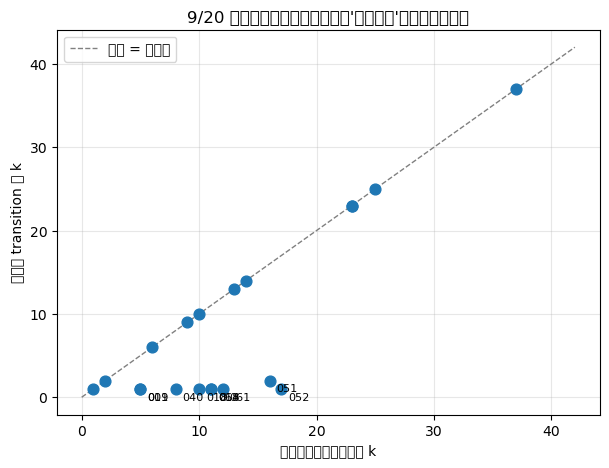

In [4]:
sel_k = {p: next(r["k"] for r in rows_by_problem[p] if r["selected"]) for p in iter_problems()}
max_k = {p: max(r["k"] for r in rows_by_problem[p] if r["status"] == "verified_proof")
         for p in iter_problems()}

plist = sorted(sel_k)
plt.figure(figsize=(7, 5))
plt.scatter([max_k[p] for p in plist], [sel_k[p] for p in plist], s=60, zorder=3)
for p in plist:
    if sel_k[p] < max_k[p]:
        plt.annotate(p.replace("fate_m_", "").replace("_v001", ""),
                     (max_k[p], sel_k[p]), textcoords="offset points", xytext=(5, -8), fontsize=8)
lim = max(max(max_k.values()), 40) + 2
plt.plot([0, lim], [0, lim], color="gray", ls="--", lw=1, label="选中 = 最高频")
plt.xlabel("该题已验证候选的最高 k")
plt.ylabel("被选中 transition 的 k")
plt.title("9/20 题选中了非最高频的变体（'最早验证'规则的副作用）")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

### 1.1 这对 CE 意味着什么（软目标动机）

对"多选题"（一道题有多个已验证变体），硬目标只押注**一条**：

- f009：4 个已验证变体，总命中 K=12，但被选中的是其中 k=1 的那个；
- f014：5 个已验证变体，被选中的 k=1，而最高频变体 k=11。

软目标（访问分布）会把整个已验证集合的概率质量都考虑进来：

In [5]:
for p in ["fate_m_009_v001", "fate_m_014_v001", "fate_m_040_v001"]:
    rows = rows_by_problem[p]
    vrows = [r for r in rows if r["status"] == "verified_proof"]
    K = sum(r["k"] for r in vrows)
    print(f"== {p} ==  已验证变体 {len(vrows)} 个，总命中 K={K}")
    for r in sorted(vrows, key=lambda r: -r["k"]):
        tag = "  ← 被选中（硬目标）" if r["selected"] else ""
        print(f"   k={r['k']:>2}   软目标权重={r['k']/K:.2f}   {r['action'][:58]!r}{tag}")
    print()

== fate_m_009_v001 ==  已验证变体 4 个，总命中 K=12
   k= 5   软目标权重=0.42   'exact curriculum_target'
   k= 4   软目标权重=0.33   'rw [curriculum_target]'
   k= 2   软目标权重=0.17   'simp only [curriculum_target, Nat.zero_div, Int.ofNat_eq_z'
   k= 1   软目标权重=0.08   'simp only [curriculum_target, Nat.zero_add, zero_add]'  ← 被选中（硬目标）

== fate_m_014_v001 ==  已验证变体 5 个，总命中 K=26
   k=11   软目标权重=0.42   'assumption'
   k=10   软目标权重=0.38   'exact curriculum_target'
   k= 2   软目标权重=0.08   'simp only [curriculum_target, eq_self_iff_true, and_self_i'
   k= 2   软目标权重=0.08   'simp only [curriculum_target, eq]'
   k= 1   软目标权重=0.04   'simp only [curriculum_target, eq, zero_pow (Nat.succ_ne_ze'  ← 被选中（硬目标）

== fate_m_040_v001 ==  已验证变体 9 个，总命中 K=20
   k= 8   软目标权重=0.40   'exact fun z ↦ curriculum_target z'
   k= 3   软目标权重=0.15   'exact fun z ↦ by obtain ⟨a, b, h⟩ := curriculum_target z; '
   k= 2   软目标权重=0.10   'exact fun z ↦curriculum_target z'
   k= 2   软目标权重=0.10   'exact fun z => curriculum_target z'
   k= 1   软目标权重

---
## 2. logprob 失准深挖

### 2.1 全体散点：记录值 vs 实际频率

如果记录准确，点应该落在那条对角线上：`log10(k/64) = -(-log10 p_model)`。
同时注意下边界的"删失线"：任何存在的候选都满足 `k ≥ 1`，即 `log10(k/64) ≥ -1.81`。

/home/a/e2-venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 35266 (\N{CJK UNIFIED IDEOGRAPH-89C2}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/a/e2-venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 27979 (\N{CJK UNIFIED IDEOGRAPH-6D4B}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/a/e2-venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 29575 (\N{CJK UNIFIED IDEOGRAPH-7387}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/a/e2-venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 36234 (\N{CJK UNIFIED IDEOGRAPH-8D8A}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/a/e2-venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 19979 (\N{CJK UNIFIED IDEOGRAPH-4E0B}) missing from font(s) 

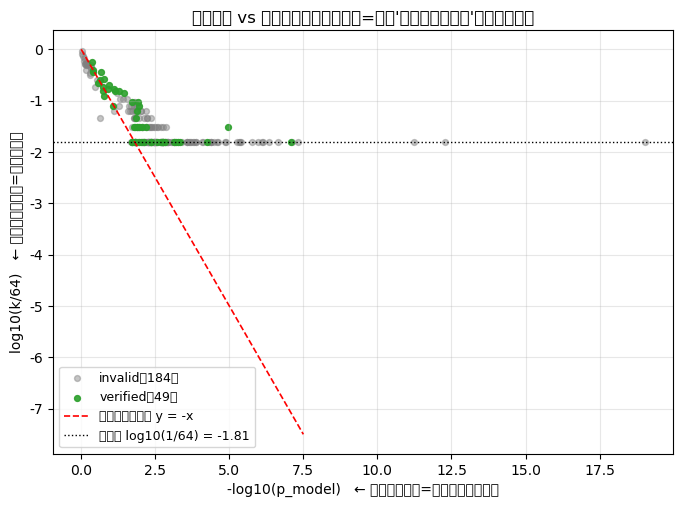

In [6]:
fig, ax = plt.subplots(figsize=(8, 5.5))
for rows, color, label, alpha in [(ALL, "gray", "invalid（184）", 0.45),
                                  ([r for r in ALL if r["status"] == "verified_proof"], "tab:green", "verified（49）", 0.9)]:
    xs, ys = [], []
    for r in rows:
        if r["status"] == "verified_proof" and label.startswith("invalid"):
            continue
        if r["status"] == "invalid_tactic" and label.startswith("verified"):
            continue
        xs.append(-r["logp_old"] / math.log(10))
        ys.append(math.log10(r["k"] / B))
    ax.scatter(xs, ys, s=18, c=color, label=label, alpha=alpha)

xs_line = np.linspace(0, 7.5, 50)
ax.plot(xs_line, -xs_line, "r--", lw=1.2, label="完美校准参考线 y = -x")
ax.axhline(math.log10(1 / B), color="black", lw=1, ls=":", label="删失线 log10(1/64) = -1.81")
ax.set_xlabel("-log10(p_model)   ← 记录值（越右=记录认为越稀有）")
ax.set_ylabel("log10(k/64)   ← 观测频率（越下=实际越少）")
ax.set_title("记录概率 vs 实际频率：右下角区域=记录'以为几乎不可能'但实际发生了")
ax.grid(alpha=0.3)
ax.legend(loc="lower left", fontsize=9)
plt.show()

### 2.2 "按记录值根本不该出现"的成功有多少？

`p_model < 1/64` 的候选，在 64 次里的**期望命中数 < 1**——记录口径下"大概率看不到"。

In [7]:
ver = [r for r in ALL if r["status"] == "verified_proof"]
inv = [r for r in ALL if r["status"] == "invalid_tactic"]

n_ver_impossible = sum(1 for r in ver if math.exp(r["logp_old"]) < 1 / B)
n_inv_impossible = sum(1 for r in inv if math.exp(r["logp_old"]) < 1 / B)
print(f"verified 中 p_model < 1/64 的: {n_ver_impossible}/49 = {n_ver_impossible/49:.1%}")
print(f"invalid  中 p_model < 1/64 的: {n_inv_impossible}/184 = {n_inv_impossible/184:.1%}")
print()
print("→ 成功组里也有近半候选，按记录值'不该在这波被看到'。")

verified 中 p_model < 1/64 的: 27/49 = 55.1%
invalid  中 p_model < 1/64 的: 142/184 = 77.2%

→ 成功组里也有近半候选，按记录值'不该在这波被看到'。


### 2.3 极端案例：fate_m_009 被选中的战术

逐 token 看它的记录值，并计算"按记录值，它在这波出现的概率有多低"：

In [8]:
p9 = "fate_m_009_v001"
cands9 = load_request(p9)["candidates"]
rows9 = rows_by_problem[p9]
sel9 = next(r for r in rows9 if r["selected"])
rc9 = cands9[sel9["survivor"]]

so = sum(rc9["raw_completion_old_logprobs"])
ss = sum(rc9["raw_completion_sampling_logprobs"])
p_model9 = math.exp(so)
p_samp9  = math.exp(ss)

print("action:", repr(sel9["action"]))
print("命中次数 k =", sel9["k"], "（64 次采样中 1 次）")
print()
print("token ids   :", rc9["raw_completion_token_ids"])
print("old  logprobs:", [round(x, 3) for x in rc9["raw_completion_old_logprobs"]])
print("samp logprobs:", [round(x, 3) for x in rc9["raw_completion_sampling_logprobs"]])
print()
print(f"Σ old  = {so:.3f}   → p_model = {p_model9:.3e}   (-lg10 = {-so/math.log(10):.2f})")
print(f"Σ samp = {ss:.3f}   → p_samp  = {p_samp9:.3e}   (-lg10 = {-ss/math.log(10):.2f})")
print()
expected = B * p_model9
print(f"按 p_model，64 次里的期望命中数 = {expected:.2e}（几乎为零）")
print(f"按 p_model，至少出现一次的概率 = {1-(1-p_model9)**B:.2e}")
print(f"实际：出现了 {sel9['k']} 次")
print(f"偏差倍数（经验频率 / p_model）≈ {sel9['k']/B / p_model9:.2e}")

action: 'simp only [curriculum_target, Nat.zero_add, zero_add]'
命中次数 k = 1 （64 次采样中 1 次）

token ids   : [20845, 1172, 508, 2352, 23136, 11123, 11, 23833, 25847, 2891, 11, 7168, 2891, 60, 151643]
old  logprobs: [-4.084, -0.046, -0.0, -0.144, -0.996, -0.0, -0.004, -0.868, -0.041, -4.413, -0.019, -0.535, -4.715, -0.475, -0.0]
samp logprobs: [-2.889, -0.124, 0.0, -0.819, -1.851, 0.0, 0.0, -0.984, -0.167, -3.267, 0.0, -0.993, -3.569, -0.54, 0.0]

Σ old  = -16.340   → p_model = 8.012e-08   (-lg10 = 7.10)
Σ samp = -15.202   → p_samp  = 2.499e-07   (-lg10 = 6.60)

按 p_model，64 次里的期望命中数 = 5.13e-06（几乎为零）
按 p_model，至少出现一次的概率 = 5.13e-06
实际：出现了 1 次
偏差倍数（经验频率 / p_model）≈ 1.95e+05


**怎么解读这个偏差？**（报告 §4 的口径警告）

1. 不能按字面理解成"记录了错误概率"——`temperature=1.5 / top_p=0.9` 的采样机制、
   以及"记录值到底在哪个分布下计算"的语义，都会让记录值**不等于**单次采样概率；
2. 更不能反过来说"这条战术其实很常见"——它的经验频率就是 1/64，**只出现一次本身
   就是稀有信号**；
3. 实操结论（E2 的做法）：
   - 窗口分析、稀有性判断 → 用**经验频率 k/64**；
   - 记录 logprob → 只当**相对排序**参考；
   - 若要用绝对概率（比如重要性权重），先做一次"记录值 vs 实测频率"的校准实验（E2b 建议）。

---
## 3. 预算 what-if：把 B' 当参数扫

发现曲线回答"某预算下能不能找到"；反过来问：**每道题需要多少预算才稳（≥90%）？**
定义 **B90** = 最小的 B' 使 P(找到 | B') ≥ 0.9。

In [9]:
def p_find(K, Bp, N=64):
    if K <= 0: return 0.0
    if Bp >= N: return 1.0
    return 1 - math.comb(N - K, Bp) / math.comb(N, Bp)

def b90(K, N=64):
    for b in range(1, N + 1):
        if p_find(K, b, N) >= 0.9:
            return b
    return None   # 64 次内达不到 90%

Kver = {p: sum(r["k"] for r in rows_by_problem[p] if r["status"] == "verified_proof")
        for p in iter_problems()}

budgets = [8, 16, 24, 32, 40, 48, 56, 64]
head = " ".join(f"{'B' + str(b):>7}" for b in budgets)
print(f"{'problem':>22} {'K_ver':>6} {'B90':>5} {head}")
for p in iter_problems():
    b90v = b90(Kver[p])
    vals = " ".join(f"{p_find(Kver[p], b):>7.3f}" for b in budgets)
    print(f"{p:>22} {Kver[p]:>6} {b90v if b90v else '—':>5} {vals}")

               problem  K_ver   B90      B8     B16     B24     B32     B40     B48     B56     B64
       fate_m_003_v001      9    14   0.725   0.939   0.990   0.999   1.000   1.000   1.000   1.000
       fate_m_004_v001      6    20   0.567   0.836   0.949   0.988   0.998   1.000   1.000   1.000
       fate_m_009_v001     12    11   0.830   0.979   0.998   1.000   1.000   1.000   1.000   1.000
       fate_m_011_v001      7    18   0.627   0.881   0.970   0.995   0.999   1.000   1.000   1.000
       fate_m_014_v001     26     5   0.989   1.000   1.000   1.000   1.000   1.000   1.000   1.000
       fate_m_015_v001     23     5   0.978   1.000   1.000   1.000   1.000   1.000   1.000   1.000
       fate_m_018_v001     12    11   0.830   0.979   0.998   1.000   1.000   1.000   1.000   1.000
       fate_m_021_v001     14     9   0.879   0.990   1.000   1.000   1.000   1.000   1.000   1.000
       fate_m_035_v001     10    13   0.765   0.957   0.994   1.000   1.000   1.000   1.000   1.000


/home/a/e2-venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 26399 (\N{CJK UNIFIED IDEOGRAPH-671F}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/a/e2-venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 26395 (\N{CJK UNIFIED IDEOGRAPH-671B}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/a/e2-venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 35299 (\N{CJK UNIFIED IDEOGRAPH-89E3}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/a/e2-venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 20986 (\N{CJK UNIFIED IDEOGRAPH-51FA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/a/e2-venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) 

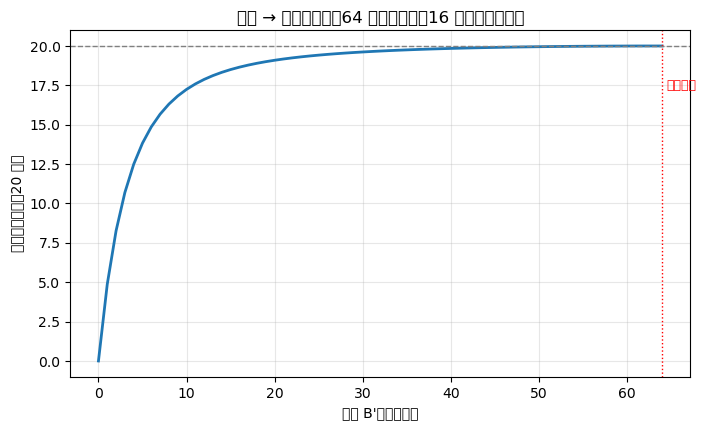

B'=16: 期望解出 18.65/20 题
B'=32: 期望解出 19.68/20 题
B'=64: 期望解出 20.00/20 题


In [10]:
xs = np.arange(0, 65)
expected_solved = [sum(p_find(Kver[p], int(b)) for p in iter_problems()) for b in xs]

plt.figure(figsize=(8, 4.5))
plt.plot(xs, expected_solved, lw=2, color="tab:blue")
plt.axvline(64, color="red", ls=":", lw=1)
plt.text(64.5, expected_solved[10], "本案预算", color="red", fontsize=9)
plt.axhline(20, color="gray", ls="--", lw=1)
plt.xlabel("预算 B'（次采样）")
plt.ylabel("期望解出题数（20 题）")
plt.title("预算 → 期望解出数：64 次几乎全解；16 次开始明显损失")
plt.grid(alpha=0.3)
plt.show()

for b in [16, 32, 64]:
    print(f"B'={b:>2}: 期望解出 {sum(p_find(Kver[p], b) for p in iter_problems()):.2f}/20 题")

### 3.1 窗对 δ 的敏感性

In [11]:
print("采样窗 θ_B = ln(1/δ)/B：")
print(f"{'B':>5} {'δ=0.05':>8} {'δ=0.1':>8} {'δ=0.2':>8}")
for b in [16, 32, 64, 128]:
    row = " ".join(f"{math.log(1/d)/b:>8.3f}" for d in (0.05, 0.1, 0.2))
    print(f"{b:>5} {row}")
print()
print("δ 越宽松（漏掉概率容忍度越高）→ 窗越低 → 更多候选被算作'有把握被找到'。")

采样窗 θ_B = ln(1/δ)/B：
    B   δ=0.05    δ=0.1    δ=0.2
   16    0.187    0.144    0.101
   32    0.094    0.072    0.050
   64    0.047    0.036    0.025
  128    0.023    0.018    0.013

δ 越宽松（漏掉概率容忍度越高）→ 窗越低 → 更多候选被算作'有把握被找到'。


---
## 4. 与本报告的核对清单

In [12]:
rows_ok = {}
# 关键数字复核
all_ver = [r for r in ALL if r["status"] == "verified_proof"]
in_win_emp = sum(1 for r in all_ver if r["k"] / B >= THETA)
check("canonical 总数 = 233", len(ALL), 233)
check("verified = 49", len(all_ver), 49)
check("window 内（经验）= 22", in_win_emp, 22)
check("selected 非最高频 = 9", len(notmax), 9)
check("P1 first-verified = 20/20", p1_ok, 20)

# f009 数字
check("f009 Σold = -16.34", round(so, 2), -16.34, tol=0.01)
check("f009 -lg10 = 7.10", round(-so / math.log(10), 2), 7.10, tol=0.01)

# B90 复核
check("f067 的 B90 = 44", b90(Kver["fate_m_067_v001"]), 44)
check("f076 的 B90 = 28", b90(Kver["fate_m_076_v001"]), 28)

n_ok = sum(1 for _, ok in CHECKS if ok)
print()
print(f"===== 核对结果: {n_ok}/{len(CHECKS)} 通过 =====")
for name, ok in CHECKS:
    if not ok:
        print("  ✗", name)

✓ canonical 总数 = 233: 233
✓ verified = 49: 49
✓ window 内（经验）= 22: 22
✓ selected 非最高频 = 9: 9
✓ P1 first-verified = 20/20: 20
✓ f009 Σold = -16.34: -16.34
✓ f009 -lg10 = 7.10: 7.1
✓ f067 的 B90 = 44: 44
✓ f076 的 B90 = 28: 28

===== 核对结果: 12/12 通过 =====


---
## 5. 练习

1. 把 §3 的 `b90` 表格按 B90 从大到小排序：最"吃预算"的是哪几题？它们的 K_ver 有什么共性？
2. 在 §2.1 的散点图里，把颜色换成"该候选是否 k=1"再画一遍，观察两种颜色的分布差异。
3. 用 `budgets = [64, 128, 256]` 重算 §3 的表：若预算翻倍到 128，
   发现概率理论上如何变化？（提示：`p_find` 的 N 不再是 64——先想清楚"翻倍"指什么。）
4. 把 §1 的规则改成"选择 k 最大的已验证候选"，用 §1.1 的 f009/f014 数据口算：
   CE 的硬目标会变成哪条？软/硬目标的差距会缩小吗？

---

**相关文件**

- 报告：`docs/diversity-mcts/reports/e2-window-audit.md`
- 审计脚本：`scripts/e2_audit_window.py`、`scripts/e2_audit_window_details.py`
- 理论背景：`docs/diversity-mcts/2-理论-多样性-可达性-吸收.md`
- 后续实验（E5 软目标、E3 搜索 vs 采样）：`docs/diversity-mcts/3-实验计划.md`